# Blood-Brain Barrier Permeability Prediction with Graph Neural Networks

Four message-passing architectures - **GCN**, **GraphSAGE**, **GIN**, **GAT** - compared on two
BBB permeability datasets. The only input is the SMILES string, converted to a molecular graph
with RDKit; no descriptors or fingerprints are used.

All four share one identical skeleton (same depth, hidden width, normalization, readout, head,
and training loop) and differ **only** in the convolution operator, so any performance gap is
attributable to the aggregation scheme rather than to capacity differences.

Evaluation uses a **balanced Bemis-Murcko scaffold split** (80/10/10): test molecules have core
structures never seen in training. Each configuration is run over 3 seeds, and the seed also
reseeds the split - so the reported spread captures split variance as well as initialization
variance.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src.datasets import load_dataset, ROOT
from src.models import MODELS
from src.split import scaffold_groups, scaffold_split

RESULTS = ROOT / 'results'

# Categorical slots validated all-pairs for CVD separation and normal-vision
# distinctness (blue / orange / aqua / violet).
COLORS = {'gcn': '#2a78d6', 'sage': '#eb6834', 'gin': '#1baf7a', 'gat': '#4a3aa7'}
LABELS = {'gcn': 'GCN', 'sage': 'GraphSAGE', 'gin': 'GIN', 'gat': 'GAT'}
DS_LABEL = {'bbbp': 'BBBP (n=1,965)', 'b3db': 'B3DB (n=7,805)'}

SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'DejaVu Sans'],
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelcolor': INK2, 'ytick.labelcolor': INK2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlepad': 12,
    'figure.dpi': 130,
})


def tidy(ax):
    """Recessive grid behind the marks, no top/right spines."""
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

/Users/shrenik/Sem_5/BioInformatics/Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. The datasets


In [2]:
reports = [json.loads((ROOT / 'data' / 'processed' / f'{n}_report.json').read_text())
           for n in ('bbbp', 'b3db')]
clean = pd.DataFrame(reports).set_index('dataset')
clean = clean.rename(columns={
    'rows_in': 'rows in', 'missing_dropped': 'missing',
    'invalid_smiles_dropped': 'invalid SMILES', 'duplicates_merged': 'dupes merged',
    'label_conflicts_dropped': 'label conflicts', 'rows_out': 'rows out'})
clean['% positive'] = (clean['positives'] / clean['rows out'] * 100).round(1)
clean

,rows in,missing,invalid SMILES,dupes merged,label conflicts,rows out,positives,negatives,% positive
dataset,,,,,,,,,
bbbp,2050,0,11,54,20,1965,1500,465,76.3
b3db,7807,0,2,0,0,7805,4956,2849,63.5


Every dropped row is accounted for. Three cleaning steps matter:

- **Invalid SMILES** - 11 rows in BBBP that RDKit cannot parse at all.
- **Duplicates** - deduplicated on the *canonical* SMILES rather than the raw string, since the
  same molecule is often written several ways across sources.
- **Label conflicts** - 20 BBBP rows where the same molecule carries contradictory labels. Every
  copy is dropped rather than guessing which is right.

The two datasets overlap substantially (B3DB aggregates BBBP as one of its sources), so they are
always trained and evaluated **independently** - training on one and testing on the other would
be a leaked evaluation.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


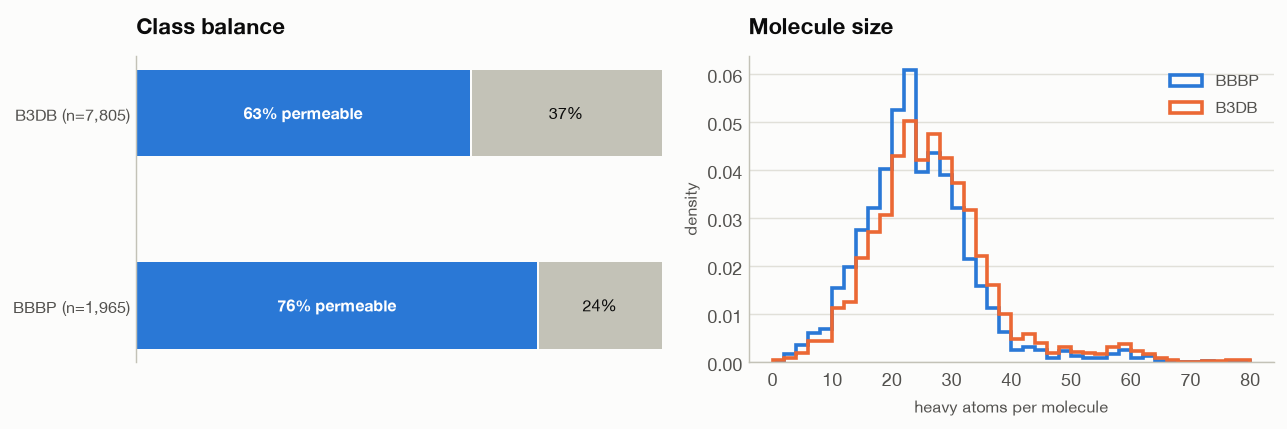

In [3]:
graphs = {n: load_dataset(n, verbose=False) for n in ('bbbp', 'b3db')}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

# Class balance: one stacked bar per dataset, 2px surface gap between segments.
ax = tidy(axes[0])
for i, n in enumerate(('bbbp', 'b3db')):
    pos = sum(int(g.y.item()) for g in graphs[n])
    neg = len(graphs[n]) - pos
    total = pos + neg
    ax.barh(i, pos / total * 100, color='#2a78d6', height=0.45)
    ax.barh(i, neg / total * 100, left=pos / total * 100 + 0.4, color='#c3c2b7', height=0.45)
    ax.text(pos / total * 50, i, f'{pos / total:.0%} permeable', ha='center', va='center',
            color='white', fontsize=9, fontweight='semibold')
    ax.text(100 - neg / total * 50, i, f'{neg / total:.0%}', ha='center', va='center',
            color=INK, fontsize=9)
ax.set_yticks([0, 1], [DS_LABEL['bbbp'], DS_LABEL['b3db']], fontsize=9)
ax.set_xlim(0, 100)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_title('Class balance', color=INK)

# Molecule size distribution.
ax = tidy(axes[1])
for n, c in (('bbbp', '#2a78d6'), ('b3db', '#eb6834')):
    sizes = [g.num_nodes for g in graphs[n]]
    ax.hist(sizes, bins=np.arange(0, 81, 2), histtype='step', linewidth=2,
            color=c, density=True, label=DS_LABEL[n].split(' (')[0])
ax.set_xlabel('heavy atoms per molecule', fontsize=9)
ax.set_ylabel('density', fontsize=9)
ax.grid(axis='y')
ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
ax.set_title('Molecule size', color=INK)

plt.tight_layout()
plt.show()

---
## 2. Why the scaffold split had to be balanced

The classic DeepChem `ScaffoldSplitter` sorts scaffold groups by size and fills train first, so
val and test receive only the smallest (singleton) scaffold groups. On `BBBP.csv` that is
**degenerate**: the file is ordered so its entire back half is class 1, and both folds come out
100% positive - ROC-AUC is undefined on a single-class fold.

The cell below reproduces that failure, then shows the balanced split used throughout.

In [4]:
smiles = {n: [g.smiles for g in graphs[n]] for n in graphs}
labels = {n: [int(g.y.item()) for g in graphs[n]] for n in graphs}

rows = []
for n in ('bbbp', 'b3db'):
    for balanced in (False, True):
        for seed in ((0,) if not balanced else (0, 1, 2)):
            tr, va, te = scaffold_split(smiles[n], seed=seed, balanced=balanced, verbose=False)
            rows.append({
                'dataset': n,
                'split': 'balanced' if balanced else 'size-sorted',
                'seed': seed,
                'train %pos': f"{np.mean([labels[n][i] for i in tr]):.1%}",
                'val %pos': f"{np.mean([labels[n][i] for i in va]):.1%}",
                'test %pos': f"{np.mean([labels[n][i] for i in te]):.1%}",
            })
pd.DataFrame(rows).set_index(['dataset', 'split', 'seed'])

train %pos val %pos test %pos
dataset split       seed                              
bbbp    size-sorted 0         70.4%   100.0%    100.0%
        balanced    0         75.6%    89.3%     69.5%
                    1         76.3%    77.0%     76.1%
                    2         75.8%    81.6%     75.1%
b3db    size-sorted 0         65.4%    69.7%     42.1%
        balanced    0         64.8%    58.2%     58.4%
                    1         64.5%    66.3%     53.0%
                    2         64.4%    54.7%     65.2%

The `size-sorted` rows for BBBP show the failure: **100% positive** in both val and test. The
balanced split shuffles scaffold groups under a per-seed RNG (routing groups too large for a fold
into train first), which removes the file-order artifact while preserving the guarantee that no
scaffold is ever shared between folds.

A fair question is whether the scaffold split is doing any real work. It is - measured by Morgan
fingerprint similarity from each test molecule to its nearest training neighbour:

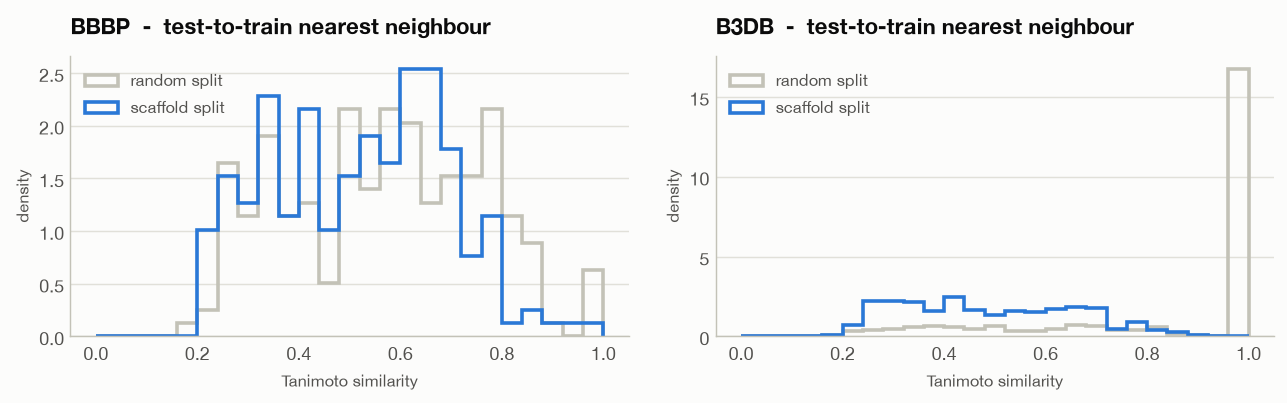

In [5]:
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Not sharey: B3DB's spike at 1.0 is tall enough to flatten the BBBP panel.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, n in zip(axes, ('bbbp', 'b3db')):
    tidy(ax)
    fps = [gen.GetFingerprint(Chem.MolFromSmiles(s)) for s in smiles[n]]
    tr, _, te = scaffold_split(smiles[n], seed=0, verbose=False)
    trf = [fps[i] for i in tr]
    scaf_nn = [max(DataStructs.BulkTanimotoSimilarity(fps[i], trf)) for i in te]

    rng = np.random.RandomState(0)
    perm = rng.permutation(len(fps))
    rte, rtr = perm[:len(te)], perm[len(te):]
    rtrf = [fps[i] for i in rtr]
    rand_nn = [max(DataStructs.BulkTanimotoSimilarity(fps[i], rtrf)) for i in rte]

    bins = np.linspace(0, 1, 26)
    ax.hist(rand_nn, bins=bins, histtype='step', linewidth=2, color='#c3c2b7',
            density=True, label='random split')
    ax.hist(scaf_nn, bins=bins, histtype='step', linewidth=2, color='#2a78d6',
            density=True, label='scaffold split')
    ax.set_title(f"{DS_LABEL[n].split(' (')[0]}  -  test-to-train nearest neighbour", color=INK)
    ax.set_xlabel('Tanimoto similarity', fontsize=9)
    ax.grid(axis='y')
    ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
    ax.set_ylabel('density', fontsize=9)
plt.tight_layout()
plt.show()

The scaffold split shifts the whole distribution left. The effect is dramatic on B3DB, where a
random split leaves a **median nearest-neighbour Tanimoto of 1.00** - more than half the test
molecules have a fingerprint-identical twin in training (stereoisomer pairs that survive
canonical-SMILES deduplication). The scaffold split keeps those pairs together in one fold.

One consequence of seeding the split: each seed defines a *different* test fold, so models can
only be combined **within** a seed. That is exactly what the ensemble section does.

---
## 3. Results


In [6]:
df = pd.read_csv(RESULTS / 'all_runs.csv')

summary = (df.groupby(['dataset', 'model'])
             .agg(roc_auc=('test_roc_auc', 'mean'), roc_sd=('test_roc_auc', 'std'),
                  pr_auc=('test_pr_auc', 'mean'), pr_sd=('test_pr_auc', 'std'),
                  bal_acc=('test_balanced_accuracy', 'mean'),
                  mcc=('test_mcc', 'mean'), mcc_sd=('test_mcc', 'std'),
                  params=('n_parameters', 'first'), secs=('train_seconds', 'mean'))
             .round(4))

table = pd.DataFrame({
    'ROC-AUC': summary.apply(lambda r: f"{r['roc_auc']:.3f} ± {r['roc_sd']:.3f}", axis=1),
    'PR-AUC': summary.apply(lambda r: f"{r['pr_auc']:.3f} ± {r['pr_sd']:.3f}", axis=1),
    'bal. acc': summary['bal_acc'].map('{:.3f}'.format),
    'MCC': summary.apply(lambda r: f"{r['mcc']:.3f} ± {r['mcc_sd']:.3f}", axis=1),
    'params': summary['params'].map('{:,}'.format),
    'sec/run': summary['secs'].map('{:.0f}'.format),
})
table

ROC-AUC         PR-AUC bal. acc            MCC   params  \
dataset model                                                                  
b3db    gat    0.884 ± 0.008  0.918 ± 0.014    0.775  0.573 ± 0.036   72,705   
        gcn    0.880 ± 0.007  0.915 ± 0.019    0.777  0.557 ± 0.016   71,937   
        gin    0.891 ± 0.009  0.921 ± 0.022    0.781  0.567 ± 0.040  121,476   
        sage   0.891 ± 0.004  0.924 ± 0.014    0.759  0.547 ± 0.061  109,697   
bbbp    gat    0.936 ± 0.045  0.973 ± 0.022    0.852  0.667 ± 0.114   72,705   
        gcn    0.936 ± 0.015  0.975 ± 0.003    0.844  0.647 ± 0.053   71,937   
        gin    0.923 ± 0.036  0.966 ± 0.018    0.834  0.605 ± 0.023  121,476   
        sage   0.929 ± 0.025  0.973 ± 0.008    0.849  0.642 ± 0.059  109,697   

              sec/run  
dataset model          
b3db    gat        60  
        gcn        41  
        gin        44  
        sage       42  
bbbp    gat        14  
        gcn        10  
        gin         9  
        sage       12

This table is also the accessible view of the charts below - every value shown as a mark is
readable here as a number.

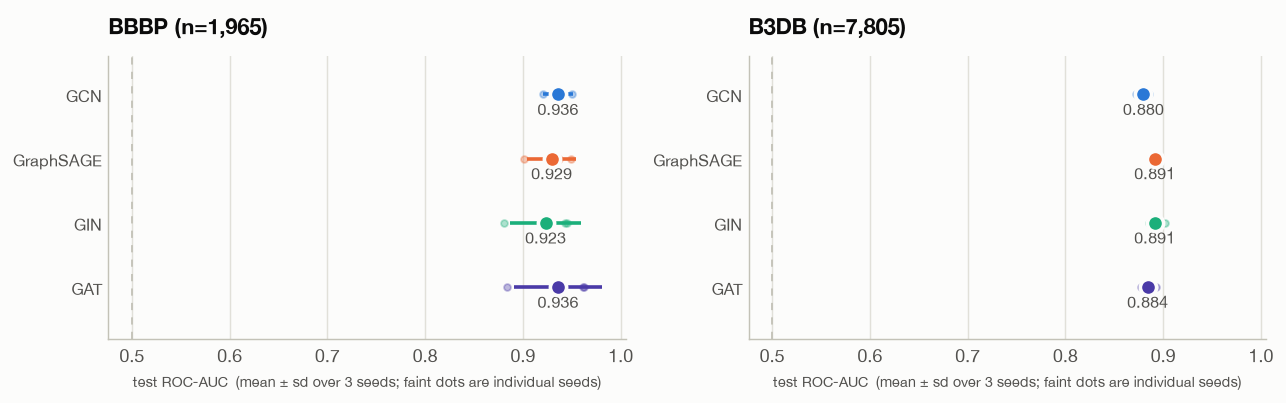

In [7]:
# Dot plot with error bars rather than bars: ROC-AUC has a meaningful floor at 0.5
# (random), so a zero-based bar axis would waste range and a truncated one would lie.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)

for ax, ds in zip(axes, ('bbbp', 'b3db')):
    tidy(ax)
    for i, m in enumerate(MODELS):
        sub = df[(df.dataset == ds) & (df.model == m)]['test_roc_auc']
        ax.errorbar(sub.mean(), i, xerr=sub.std(), fmt='o', markersize=9,
                    color=COLORS[m], ecolor=COLORS[m], elinewidth=2, capsize=0,
                    markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
        ax.scatter(sub, [i] * len(sub), s=14, color=COLORS[m], alpha=0.35, zorder=2)
        ax.text(sub.mean(), i + 0.32, f'{sub.mean():.3f}', ha='center', fontsize=9,
                color=INK2)
    ax.axvline(0.5, color=AXIS, linewidth=1, linestyle=(0, (4, 4)), zorder=1)
    ax.set_yticks(range(len(MODELS)), [LABELS[m] for m in MODELS], fontsize=9)
    ax.set_ylim(-0.6, len(MODELS) - 0.2)
    ax.invert_yaxis()
    ax.grid(axis='x')
    ax.set_title(DS_LABEL[ds], color=INK)
    ax.set_xlabel('test ROC-AUC  (mean ± sd over 3 seeds; faint dots are individual seeds)',
                  fontsize=8)

plt.tight_layout()
plt.show()

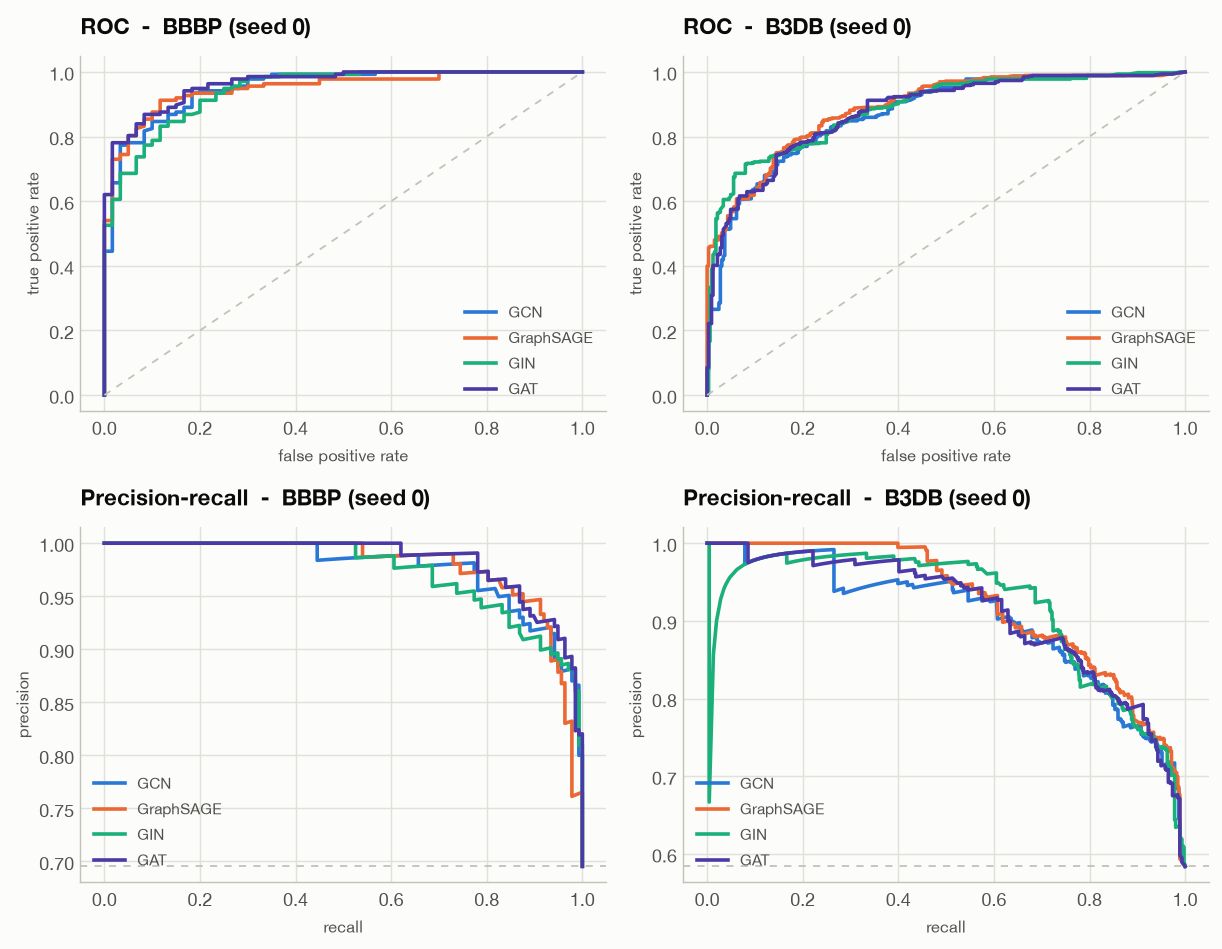

In [8]:
from sklearn.metrics import precision_recall_curve, roc_curve

# Folds differ per seed, so curves are drawn on a single seed's fold (seed 0).
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.4))

for col, ds in enumerate(('bbbp', 'b3db')):
    for m in MODELS:
        d = np.load(RESULTS / ds / m / 'seed0' / 'test_preds.npz')
        fpr, tpr, _ = roc_curve(d['y'], d['prob'])
        axes[0, col].plot(fpr, tpr, linewidth=2, color=COLORS[m], label=LABELS[m])
        prec, rec, _ = precision_recall_curve(d['y'], d['prob'])
        axes[1, col].plot(rec, prec, linewidth=2, color=COLORS[m], label=LABELS[m])
        baseline = d['y'].mean()

    ax = tidy(axes[0, col])
    ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1, linestyle=(0, (4, 4)))
    ax.set_title(f"ROC  -  {DS_LABEL[ds].split(' (')[0]} (seed 0)", color=INK)
    ax.set_xlabel('false positive rate', fontsize=9)
    ax.set_ylabel('true positive rate', fontsize=9)

    ax = tidy(axes[1, col])
    ax.axhline(baseline, color=AXIS, linewidth=1, linestyle=(0, (4, 4)))
    ax.set_title(f"Precision-recall  -  {DS_LABEL[ds].split(' (')[0]} (seed 0)", color=INK)
    ax.set_xlabel('recall', fontsize=9)
    ax.set_ylabel('precision', fontsize=9)

for row, ax in enumerate(axes.ravel()):
    ax.grid(True)
    # PR curves run top-left to bottom-right, so the lower-left corner is free.
    loc = 'lower right' if row < 2 else 'lower left'
    ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2, loc=loc)

plt.tight_layout()
plt.show()

---
## 4. Ensembling

Within a seed all four models share an identical scaffold split, so their saved predictions are
index-aligned and can be combined. Three strategies are compared against the individual models:

- **soft vote** - mean of the four predicted probabilities.
- **rank average** - mean of the four per-model rank orderings; scale-free, so a poorly
  calibrated but well-ranked model is not penalised.
- **stacking** - logistic regression over the four probabilities, fit on the **validation** fold
  (which the base models were early-stopped on but never trained on).

In [9]:
from src.ensemble import run as run_ensemble

ens = run_ensemble()
agg = (ens.groupby(['dataset', 'kind', 'method'])['roc_auc']
          .agg(['mean', 'std']).round(4).sort_values('mean', ascending=False))
agg

mean     std
dataset kind     method                   
bbbp    ensemble soft_vote  0.9396  0.0258
                 rank_avg   0.9387  0.0299
                 stacking   0.9386  0.0268
        single   gat        0.9358  0.0453
                 gcn        0.9358  0.0151
                 sage       0.9293  0.0248
                 gin        0.9232  0.0364
b3db    ensemble stacking   0.8977  0.0042
                 soft_vote  0.8961  0.0046
                 rank_avg   0.8950  0.0042
        single   gin        0.8913  0.0093
                 sage       0.8913  0.0038
                 gat        0.8841  0.0076
                 gcn        0.8798  0.0070

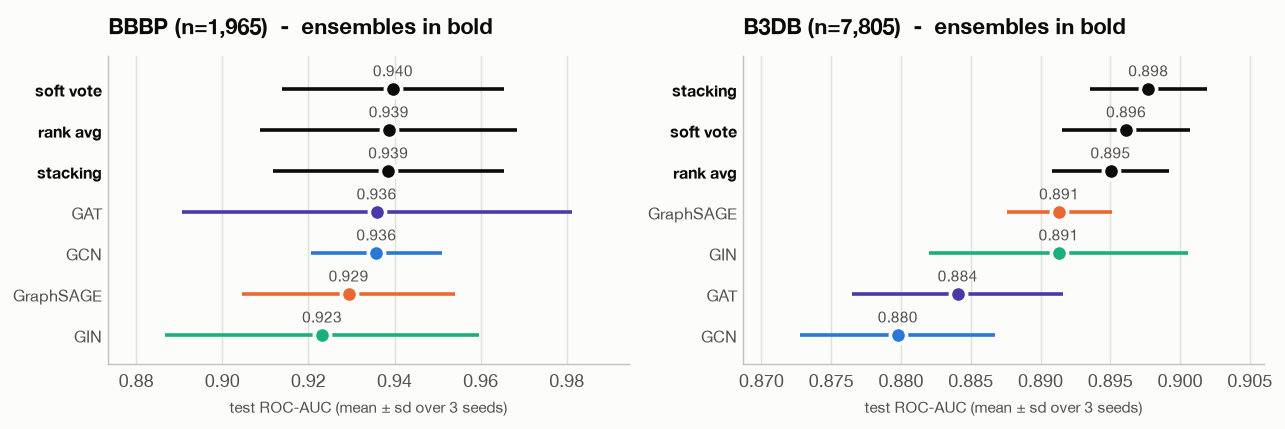

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharex=False)
ENS_COLOR = '#0b0b0b'

for ax, ds in zip(axes, ('bbbp', 'b3db')):
    tidy(ax)
    sub = (ens[ens.dataset == ds].groupby(['kind', 'method'])['roc_auc']
             .agg(auc='mean', sd='std').reset_index().sort_values('auc'))
    for i, r in enumerate(sub.itertuples()):
        colour = COLORS.get(r.method, ENS_COLOR)
        ax.errorbar(r.auc, i, xerr=r.sd, fmt='o', markersize=9, color=colour,
                    ecolor=colour, elinewidth=2, capsize=0,
                    markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
        ax.text(r.auc, i + 0.3, f'{r.auc:.3f}', ha='center', fontsize=8.5, color=INK2)
    names = [LABELS.get(m, m.replace('_', ' ')) for m in sub['method']]
    weights = ['semibold' if k == 'ensemble' else 'normal' for k in sub['kind']]
    ax.set_yticks(range(len(sub)), names, fontsize=9)
    for tick, w in zip(ax.get_yticklabels(), weights):
        tick.set_fontweight(w)
        tick.set_color(INK if w == 'semibold' else INK2)
    ax.set_ylim(-0.7, len(sub) - 0.2)
    ax.margins(x=0.14)  # keep the error bars off the axis edge
    ax.grid(axis='x')
    ax.set_title(f"{DS_LABEL[ds]}  -  ensembles in bold", color=INK)
    ax.set_xlabel('test ROC-AUC (mean ± sd over 3 seeds)', fontsize=8.5)

plt.tight_layout()
plt.show()

In [11]:
# What weight did the stacker learn for each model?
pd.read_csv(RESULTS / 'stack_weights.csv').set_index(['dataset', 'seed']).round(2)

gcn  sage   gin   gat
dataset seed                        
bbbp    0     1.16  1.02  1.80  1.27
        1     1.01  1.88  1.20  1.35
        2     1.47  0.88  1.87  0.96
b3db    0     0.30  1.91  2.70  0.48
        1     0.60  2.94  2.14  1.33
        2     1.52  1.00  2.40  1.42

---
## 5. Notes on reading these numbers

**The absolute values are protocol-dependent.** Frequently quoted BBBP scaffold-split figures near
0.65-0.70 come from DeepChem's *size-sorted* splitter, which deliberately routes the rarest
scaffolds into test. That splitter is unusable here (it produces single-class folds on BBBP), so
these results use the balanced scaffold protocol, for which the comparable published range is
around 0.90. Numbers from the two protocols are not interchangeable.

**Seed spread includes split variance.** Because the seed reseeds the scaffold partition, the ±
figures are wider - and more honest - than init-only variance would be.

**Bond features are computed but unused.** `Data.edge_attr` carries bond type, conjugation, and
ring membership, but no model consumes it: GCN and GraphSAGE structurally cannot, so feeding it to
GIN/GAT alone would confound the architecture comparison with an input-signal advantage. Swapping
`GINConv` for `GINEConv` is the natural follow-up ablation.